# Dataset-Agnostic Variational Quantum Estimators

Use the sklearn-like `QuantumClassifier` and `QuantumRegressor` APIs on compact supervised tasks. The examples call the new estimators directly instead of assembling circuits in the notebook.

## Tutorial Goals

This tutorial uses sklearn-like variational quantum estimators directly. You will:

- fit `QuantumClassifier` on a multiclass task
- inspect class probabilities and fitted attributes
- fit `QuantumRegressor` on a multi-output task
- compare results against simple classical baselines

Use this notebook when adapting the variational models to custom arrays.

## Problem, Variables, and Quantum Advantage Context

**Learning problem.** The classifier identifies three compact operating regimes from two features. The regressor predicts two coupled response channels from the same two-feature input.

**Explicit variables.** `x_class` and `y_class` are the multiclass classification dataset. `class_probabilities` are one-vs-rest probabilities from `QuantumClassifier`. `x_reg` and `y_reg` are the multi-output regression dataset. `q_reg_pred` is the two-column prediction matrix from `QuantumRegressor`.

**Quantum advantage context.** Variational quantum estimators can learn nonlinear decision and response surfaces through parameterized circuits. This notebook does **not** claim quantum advantage; it validates the new dataset-agnostic estimator API and compares against simple classical baselines.

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
elif not (repo_root / "src" / "qml").exists():
    repo_root = next((parent for parent in repo_root.parents if (parent / "src" / "qml").exists()), repo_root)

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt

from qml import QuantumClassifier, QuantumRegressor
from qml.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from qml.reporting import print_section


## Domain simulator

The examples use deterministic synthetic regimes so the notebook is fast and reproducible while still exercising multiclass classification and multi-output regression.

In [2]:
rng = np.random.default_rng(41)

centers = np.asarray([[0.0, 0.0], [1.0, 0.0], [-0.3, 0.9]])
x_class = np.vstack([rng.normal(center, 0.08, size=(5, 2)) for center in centers])
y_class = np.repeat([0, 1, 2], 5)

class_scaler = StandardScaler()
x_class_scaled = class_scaler.fit_transform(x_class)

x_reg = np.asarray(
    [
        [0.0, 0.0],
        [0.2, 0.1],
        [0.4, 0.3],
        [0.6, 0.5],
        [0.8, 0.7],
        [1.0, 1.0],
    ],
    dtype=float,
)
y_reg = np.column_stack([0.8 * x_reg[:, 0] - 0.2, 0.6 * x_reg[:, 1] - 0.1])
reg_scaler = StandardScaler()
x_reg_scaled = reg_scaler.fit_transform(x_reg)

print_section(
    "Dataset",
    [
        ("Classification samples", int(len(y_class))),
        ("Classification feature_shape", list(x_class.shape)),
        ("Classes", sorted(np.unique(y_class).tolist())),
        ("Regression samples", int(len(y_reg))),
        ("Regression feature_shape", list(x_reg.shape)),
        ("Regression target_shape", list(y_reg.shape)),
    ],
)

Dataset
+------------------------------+-----------+
| Metric                       | Value     |
+------------------------------+-----------+
| Classification samples       | 15        |
| Classification feature_shape | [15, 2]   |
| Classes                      | [0, 1, 2] |
| Regression samples           | 6         |
| Regression feature_shape     | [6, 2]    |
| Regression target_shape      | [6, 2]    |
+------------------------------+-----------+



## Package-client variational estimators

In [3]:
q_classifier = QuantumClassifier(n_layers=1, steps=10, step_size=0.08, seed=41)
q_classifier.fit(x_class_scaled, y_class)
class_probabilities = q_classifier.predict_proba(x_class_scaled)
q_class_pred = q_classifier.predict(x_class_scaled)

svc_baseline = SVC(kernel="rbf", gamma="scale")
svc_baseline.fit(x_class_scaled, y_class)
svc_class_pred = svc_baseline.predict(x_class_scaled)

q_regressor = QuantumRegressor(n_layers=1, steps=10, step_size=0.07, seed=42)
q_regressor.fit(x_reg_scaled, y_reg)
q_reg_pred = q_regressor.predict(x_reg_scaled)

ridge_baseline = Ridge(alpha=1e-3)
ridge_baseline.fit(x_reg_scaled, y_reg)
ridge_reg_pred = ridge_baseline.predict(x_reg_scaled)

classifier_loss_history = np.asarray(q_classifier.loss_history_, dtype=float)
regressor_loss_history = np.asarray(q_regressor.loss_history_, dtype=float)

results = {
    "quantum_classifier_accuracy": accuracy_score(y_class, q_class_pred),
    "svc_classifier_accuracy": accuracy_score(y_class, svc_class_pred),
    "quantum_regression_mae": mean_absolute_error(y_reg, q_reg_pred),
    "quantum_regression_mse": mean_squared_error(y_reg, q_reg_pred),
    "ridge_regression_mae": mean_absolute_error(y_reg, ridge_reg_pred),
    "classifier_initial_loss_mean": float(classifier_loss_history[:, 0].mean()),
    "classifier_final_loss_mean": float(classifier_loss_history[:, -1].mean()),
    "regressor_initial_loss_mean": float(regressor_loss_history[:, 0].mean()),
    "regressor_final_loss_mean": float(regressor_loss_history[:, -1].mean()),
}

print_section(
    "Results",
    [
        ("Quantum classifier accuracy", results["quantum_classifier_accuracy"]),
        ("SVC classifier accuracy", results["svc_classifier_accuracy"]),
        ("Quantum regression MAE", results["quantum_regression_mae"]),
        ("Quantum regression MSE", results["quantum_regression_mse"]),
        ("Ridge regression MAE", results["ridge_regression_mae"]),
        ("Classifier initial loss mean", results["classifier_initial_loss_mean"]),
        ("Classifier final loss mean", results["classifier_final_loss_mean"]),
        ("Regressor initial loss mean", results["regressor_initial_loss_mean"]),
        ("Regressor final loss mean", results["regressor_final_loss_mean"]),
    ],
)

Results
+------------------------------+-------------+
| Metric                       | Value       |
+------------------------------+-------------+
| Quantum classifier accuracy  | 0.666667    |
| SVC classifier accuracy      | 1           |
| Quantum regression MAE       | 0.393804    |
| Quantum regression MSE       | 0.207483    |
| Ridge regression MAE         | 0.000269655 |
| Classifier initial loss mean | 0.776098    |
| Classifier final loss mean   | 0.392458    |
| Regressor initial loss mean  | 0.34266     |
| Regressor final loss mean    | 0.211391    |
+------------------------------+-------------+



## Plots

The plots show multiclass predictions, mean training-loss curves, and the two-output regression predictions.

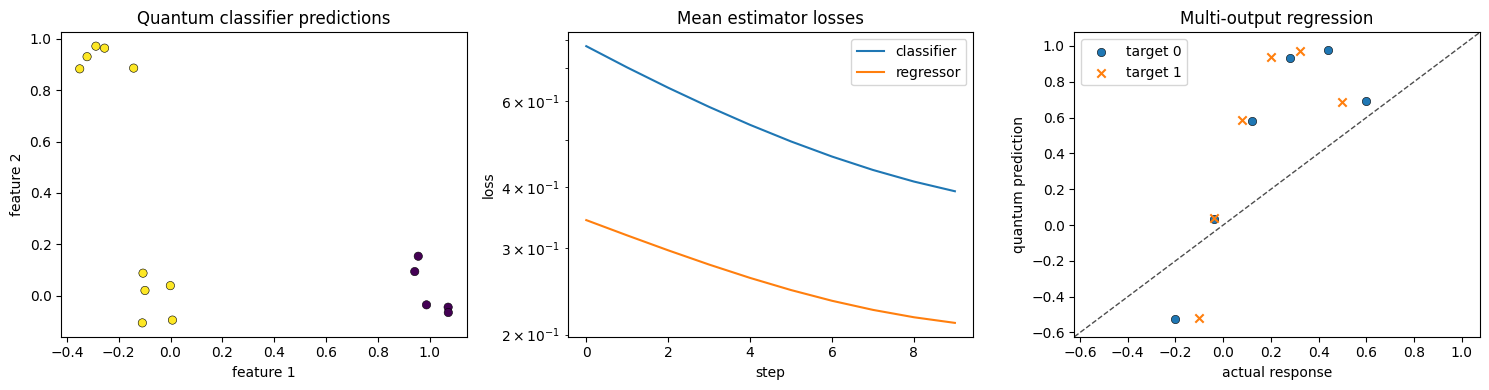

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x_class[:, 0], x_class[:, 1], c=q_class_pred, cmap="viridis", edgecolor="black", linewidth=0.4)
axes[0].set_title("Quantum classifier predictions")
axes[0].set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")

axes[1].plot(classifier_loss_history.mean(axis=0), label="classifier", color="tab:blue")
axes[1].plot(regressor_loss_history.mean(axis=0), label="regressor", color="tab:orange")
axes[1].set_title("Mean estimator losses")
axes[1].set_xlabel("step")
axes[1].set_ylabel("loss")
axes[1].set_yscale("log")
axes[1].legend()

axes[2].scatter(y_reg[:, 0], q_reg_pred[:, 0], label="target 0", edgecolor="black", linewidth=0.4)
axes[2].scatter(y_reg[:, 1], q_reg_pred[:, 1], label="target 1", marker="x")
low = min(y_reg.min(), q_reg_pred.min()) - 0.1
high = max(y_reg.max(), q_reg_pred.max()) + 0.1
axes[2].plot([low, high], [low, high], color="0.3", linestyle="--", linewidth=1)
axes[2].set_xlim(low, high)
axes[2].set_ylim(low, high)
axes[2].set_title("Multi-output regression")
axes[2].set_xlabel("actual response")
axes[2].set_ylabel("quantum prediction")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell checks the fitted estimator attributes, probability normalization, loss reduction, and finite predictions.

In [5]:
validation = {
    "dataset": {
        "problem": "dataset_agnostic_variational_estimators",
        "classification_features": ["feature_1", "feature_2"],
        "classification_target": "operating_regime",
        "regression_features": ["input_1", "input_2"],
        "regression_targets": ["response_channel_1", "response_channel_2"],
        "n_class_samples": int(len(y_class)),
        "n_reg_samples": int(len(y_reg)),
    },
    "results": results,
    "sample_class_predictions": [
        {"actual": int(a), "quantum": int(q), "svc": int(s), "probabilities": probs.tolist()}
        for a, q, s, probs in zip(y_class[:6], q_class_pred[:6], svc_class_pred[:6], class_probabilities[:6])
    ],
    "sample_regression_predictions": [
        {"actual": actual.tolist(), "quantum": quantum.tolist(), "ridge": ridge.tolist()}
        for actual, quantum, ridge in zip(y_reg[:4], q_reg_pred[:4], ridge_reg_pred[:4])
    ],
    "passed": bool(
        hasattr(q_classifier, "classes_")
        and hasattr(q_regressor, "n_outputs_")
        and np.allclose(class_probabilities.sum(axis=1), 1.0)
        and np.isfinite(q_reg_pred).all()
        and results["quantum_classifier_accuracy"] >= 0.6
        and results["quantum_regression_mae"] < 0.55
        and results["classifier_final_loss_mean"] < results["classifier_initial_loss_mean"]
        and results["regressor_final_loss_mean"] < results["regressor_initial_loss_mean"]
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Classification features", validation["dataset"]["classification_features"]),
        ("Classification target", validation["dataset"]["classification_target"]),
        ("Regression features", validation["dataset"]["regression_features"]),
        ("Regression targets", validation["dataset"]["regression_targets"]),
        ("Classification samples", validation["dataset"]["n_class_samples"]),
        ("Regression samples", validation["dataset"]["n_reg_samples"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum classifier accuracy", validation["results"]["quantum_classifier_accuracy"]),
        ("SVC classifier accuracy", validation["results"]["svc_classifier_accuracy"]),
        ("Quantum regression MAE", validation["results"]["quantum_regression_mae"]),
        ("Quantum regression MSE", validation["results"]["quantum_regression_mse"]),
        ("Ridge regression MAE", validation["results"]["ridge_regression_mae"]),
        ("Classifier initial loss mean", validation["results"]["classifier_initial_loss_mean"]),
        ("Classifier final loss mean", validation["results"]["classifier_final_loss_mean"]),
        ("Regressor initial loss mean", validation["results"]["regressor_initial_loss_mean"]),
        ("Regressor final loss mean", validation["results"]["regressor_final_loss_mean"]),
    ],
)
print("Sample class predictions")
for index, row in enumerate(validation["sample_class_predictions"], start=1):
    probs = [round(float(value), 4) for value in row["probabilities"]]
    print(f"{index}. Actual: {row['actual']}, Quantum: {row['quantum']}, SVC: {row['svc']}, Probabilities: {probs}")
print()
print("Sample regression predictions")
for index, row in enumerate(validation["sample_regression_predictions"], start=1):
    print(
        f"{index}. Actual: {[round(v, 6) for v in row['actual']]}, "
        f"Quantum: {[round(v, 6) for v in row['quantum']]}, "
        f"Ridge: {[round(v, 6) for v in row['ridge']]}"
    )
print()
print("Interpretation")
print("The sklearn-like quantum estimators fit, expose learned attributes, and return finite predictions.")
print("The validation threshold is intentionally modest because this notebook is an API usage example, not a benchmark claim.")
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+-------------------------+------------------------------------------+
| Metric                  | Value                                    |
+-------------------------+------------------------------------------+
| Problem                 | dataset_agnostic_variational_estimators  |
| Classification features | [feature_1, feature_2]                   |
| Classification target   | operating_regime                         |
| Regression features     | [input_1, input_2]                       |
| Regression targets      | [response_channel_1, response_channel_2] |
| Classification samples  | 15                                       |
| Regression samples      | 6                                        |
+-------------------------+------------------------------------------+

Results
+------------------------------+-------------+
| Metric                       | Value       |
+------------------------------+-------------+
| Quantum classifier accuracy  | 0.666667    |
| S